# Predicting the progression of diabetes using least-squares regression

The **diabetes** data set is provided as a single file, `diabetes-data.csv`. We obtained it at https://web.stanford.edu/~hastie/Papers/LARS/diabetes.data. For some background information on the data, see this seminal paper:

Bradley Efron, Trevor Hastie, Iain Johnstone and Robert Tibshirani (2004) "Least Angle Regression," Annals of Statistics (with discussion), 407-499.

## Set up notebook and load data set

In [210]:
# Standard includes
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# Routines for linear regression
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
# Set label size for plots
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14)

This next snippet of code loads in the diabetes data. There are 442 data points, each with 10 predictor variables (which we'll denote `x`) and one response variable (which we'll denote `y`).

Make sure the file `'diabetes-data.csv'` is in the same directory as this notebook.

In [211]:
data = np.genfromtxt('diabetes-data.csv', delimiter=',')
features = ['age', 'sex', 'body mass index', 'blood pressure', 
            'serum1', 'serum2', 'serum3', 'serum4', 'serum5', 'serum6']
x = data[:,0:10] # predictors
y = data[:,10] # response variable


## Predict `y` without using `x`

If we want to predict `y` without knowledge of `x`, what value would be predict? The <font color="magenta">mean</font> value of `y`.

In this case, the mean squared error (MSE) associated with the prediction is simply the variance of `y`.

In [212]:
print ("Prediction: ", np.mean(y))
print ("Mean squared error: ", np.var(y))

Prediction:  152.13348416289594
Mean squared error:  5929.884896910383


## 1. a- Predict `y` using a single feature of `x`

To fit a linear regression model, we could directly use the formula we saw in lecture. To make things even easier, this is already implemented in `sklearn.linear_model.LinearRegression()`.

Here we define a function, **one_feature_regression**, that takes `x` and `y`, along with the index `f` of a single feature and fits a linear regressor to `(x[f],y)`. It then plots the data along with the resulting line.

In [ ]:
def one_feature_regression(x,y,f):
    if (f < 0) or (f > 9):
        print ("Feature index is out of bounds")
        return
    x1 = x[:,[f]]
    
    #Craete an object of linear regression
    regr = linear_model.LinearRegression()
    # call the fit method to fit the regression model
    regr.fit(x1, y)
    
    # Make predictions using the model
    y_pred = regr.predict(x1)
    
    # Plotting the data points and predictions
    plt.plot(x1, y, 'bo')
    plt.plot(x1, y_pred, 'r-', linewidth=3)
    plt.xlabel(features[f], fontsize=14)
    plt.ylabel('Progression of disease', fontsize=14)
    plt.show()
    print ("Mean squared error: ", mean_squared_error(y, y_pred))
    return regr

Let's try this with feature #2 (body mass index).

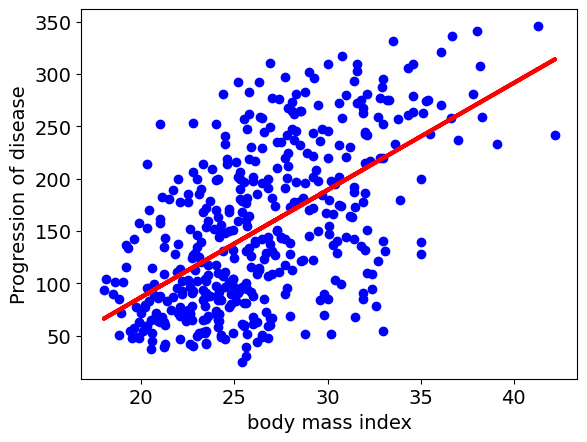

Mean squared error:  3890.456585461273
w =  [10.23312787]
b =  -117.77336656656527


In [214]:
regr = one_feature_regression(x,y,2)
print ("w = ", regr.coef_)
print ("b = ", regr.intercept_)

## b- Feature #2 ('body mass index') is the single feature that yields the lowest mean squared error. Which feature is the second best?

In [215]:
### You can use this space to figure out the second-best feature

## I will try to test all the other features to see the second lowest MSE

mse_list = []

for f in range(10):
    x1 = x[:, [f]]
    regr = linear_model.LinearRegression()
    regr.fit(x1, y)
    y_pred = regr.predict(x1)
    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)
    print("Feature %d: %s, MSE = %.2f" % (f, features[f], mse))
    
# Sorting by MSE (the lower the better)
sorted_features = sorted(enumerate(mse_list), key = lambda k : k[1])
print()
print("Second best feature: %d - %s" % (sorted_features[1][0], features[sorted_features[1][0]]))


Feature 0: age, MSE = 5720.55
Feature 1: sex, MSE = 5918.89
Feature 2: body mass index, MSE = 3890.46
Feature 3: blood pressure, MSE = 4774.11
Feature 4: serum1, MSE = 5663.32
Feature 5: serum2, MSE = 5750.24
Feature 6: serum3, MSE = 5005.66
Feature 7: serum4, MSE = 4831.14
Feature 8: serum5, MSE = 4031.00
Feature 9: serum6, MSE = 5062.38

Second best feature: 8 - serum5


## 2. Predict `y` using a specified subset of features from `x`

The function **feature_subset_regression** is just like **one_feature_regression**, but this time uses a list of features `flist`.

In [ ]:
def feature_subset_regression(x,y,flist):
    if len(flist) < 1:
        print ("Need at least one feature")
        return
    for f in flist:
        if (f < 0) or (f > 9):
            print ("Feature index is out of bounds")
            return

    #Craete an object of linear regression
    regr = linear_model.LinearRegression()
    # call the fit method to fit the regression model
    Xsub = x[:, flist]
    regr.fit(Xsub, y)
    

    return regr

Try using just features #2 (body mass index) and #8 (serum5).

In [217]:
flist = [2,8]
regr = feature_subset_regression(x,y,[2,8])
print ("w = ", regr.coef_)
print ("b = ", regr.intercept_)
print ("Mean squared error: ", mean_squared_error(y, regr.predict(x[:,flist])))

w =  [ 7.27600054 56.05638703]
b =  -299.95751508023613
Mean squared error:  3205.190076824853


Finally, use all 10 features.

In [218]:
regr = feature_subset_regression(x,y,range(0,10))
print ("w = ", regr.coef_)
print ("b = ", regr.intercept_) 
print ("Mean squared error: ", mean_squared_error(y, regr.predict(x)))

w =  [-3.63612242e-02 -2.28596481e+01  5.60296209e+00  1.11680799e+00
 -1.08999633e+00  7.46450456e-01  3.72004715e-01  6.53383194e+00
  6.84831250e+01  2.80116989e-01]
b =  -334.56713851878783
Mean squared error:  2859.69634758675


## Splitting the data into a training and test set

We define a procedure **split_data** that partitions the data set into separate training and test sets. It is invoked as follows:

* `trainx, trainy, testx, testy = split_data(n_train)`

Here:
* `n_train` is the desired number of training points
* `trainx` and `trainy` are the training points and response values
* `testx` and `testy` are the test points and response values

The split is done randomly, but the random seed is fixed, and thus the same split is produced if the procedure is called repeatedly with the same `n_train` parameter.
**Note:** You can also use python built-in libraries for splitting data like:
`from sklearn.model_selection import train_test_split`

In [219]:
def split_data(n_train):
    if (n_train < 0) or (n_train > 442):
        print ("Invalid number of training points")
        return
    np.random.seed(0)
    perm = np.random.permutation(442)
    training_indices = perm[range(0,n_train)]
    test_indices = perm[range(n_train,442)]
    trainx = x[training_indices,:]
    trainy = y[training_indices]
    testx = x[test_indices,:]
    testy = y[test_indices]
    return trainx, trainy, testx, testy

In [220]:
#### ADDITIONAL STEP ####

### Data Standardization using StandardScaler

# Gradient descent is sensitive to the scale of features.
# If the features have very different magnitudes, the algorithm may converge slowly
# or even diverge because the gradient updates become unbalanced.
# Therefore, we standardize the data so that each feature has zero mean and unit variance.
# This will make sure that all features contribute equally to the optimization process,
# allowing gradient descent to converge faster and more stably.
# and can also improve numerical precision in the closed-form solution.

from sklearn.preprocessing import StandardScaler

def scale_with_training(trainx, testx):
    """Fit scaler on trainx and apply to both trainx and testx."""
    
    scaler = StandardScaler()
    trainx = scaler.fit_transform(trainx) # fit only on training data
    testx = scaler.transform(testx) # use same mean/std for test data
    
    return trainx, testx, scaler


## 3. Implementing the closed-form solution

We define a procedure **split_data** that partitions the data set into separate training and test sets. It is invoked as follows:

* `trainx, trainy, testx, testy = split_data(n_train)`

Here:
* `n_train` is the desired number of training points
* `trainx` and `trainy` are the training points and response values
* `testx` and `testy` are the test points and response values

The split is done randomly, but the random seed is fixed, and thus the same split is produced if the procedure is called repeatedly with the same `n_train` parameter.
**Note:** You can also use python built-in libraries for splitting data like:
`from sklearn.model_selection import train_test_split`

To fit a linear regression model, we can directly use the closed-form formula we saw in lecture. Implement a method to get the parameters of the linear regression using the closed-form solution. The method should take features `x` and predictions `y` of the training set and return back the parameter values including the bias term.

In [ ]:
def linear_regression_CF(trainx, trainy):
    # inputs: trainx and trainy, the features and the target in the training set
    # output: a vector of weights including the bias term
    
    #1. Augment X with a bias column of ones
    Xb = np.c_[trainx, np.ones(trainx.shape[0])]

    #2. Theta = (X^T X)^(-1) X^T y = pinv(X) @ y -> using pinv for numerical stability
    theta = np.linalg.pinv(Xb) @ trainy

    return theta


## 4. Implementing the iterative solution

In this section, you you are required to implement the iterative (gradient descent) solution. The method should take features `x` and predictions `y` of the training set and return back the parameter values including the bias term. You should also initialize the hyper-parameters in the beginning of the method. Also, plot the the cost function at different iterations.
Here, the input consists of:
* training data `trainx, trainy`, where `trainx` and `trainy` are numpy arrays of dimension `m`-by-`n` and `m`, respectively (if there are `m` training points and `n` features)

The function should find the `n`-dimensional vector `w` and offset `b` that minimize the MSE loss function, and return:
* `w` and `b`
* `losses`, an array containing the MSE loss at each iteration

<font color="magenta">Advice:</font> First figure out the derivative, which has a relatively simple form. Next, when implementing gradient descent, think carefully about two issues.

1. What is the step size (learning rate)?
2. When has the procedure converged?

Take the time to experiment with different ways of handling these.

**Note:** You can use additional methods as helpers if you feel the need.

**Note:** MSE is the RSS value divided by the number of samples to get the mean.

In [ ]:
def linear_regression_GD(trainx, trainy, p = True):
    # inputs: trainx and trainy, the features and the target in the training set
    # output: a vector of weights including the bias term
    
    # Initializing the hypter-parameters explicitly
    alpha = 0.001
    max_iteration = 20000
    tolerance = 1e-8 # This is for the converging threshold
    
    #Initializing the parameters
    m, n = trainx.shape
    w = np.zeros(n)
    b = 0.0
    losses = []

    # Gradient Descent Loop
    for iteration in range(max_iteration):
        
        # Predictions and residuals
        y_hat = trainx @ w + b
        residual = y_hat - trainy

        # MSE (Mean RSS)
        loss = (residual @ residual) / m
        losses.append(loss)

        # Gradients of MSE
        grad_w = (2.0 / m) * (trainx.T @ residual) # (n, )
        grad_b = (2.0 / m) * residual.sum() # a scalar

        # Parameter update
        w = w - alpha * grad_w
        b = b - alpha * grad_b

        # Convergence check (if there is relative improvement in the loss)
        if len(losses) > 1 and abs(losses[-2] - losses[-1]) < tolerance * max(1.0, losses[-2]):
            print("Converged after %d iterations." % iteration)
            break

    # Plotting the cost function at different iterations (using a helper method)
    plot_cost_function(losses, plot = p)
    
    # return weights, bias, and the list of MSE values across iterations
    return w, b, np.array(losses)

def plot_cost_function(losses, plot = True):
    """Helper function to plot the cost (MSE) over iterations."""
    if plot:
        plt.figure(figsize=(6,4))
        plt.plot(losses, color='royalblue', linewidth=2)
        plt.xlabel("Iteration", fontsize=12)
        plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
        plt.title("Gradient Descent Convergence", fontsize=14)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    

## 5. a- Use different amounts of training data to fit the model

Using the **split_data** procedure to partition the data set, compute the training MSE and test MSE when fitting a regressor to *all* features, for the following training set sizes:
* `n_train = 20`
* `n_train = 50`
* `n_train = 100`
* `n_train = 200`
* `n_train = 300`




Training with n_train = 20


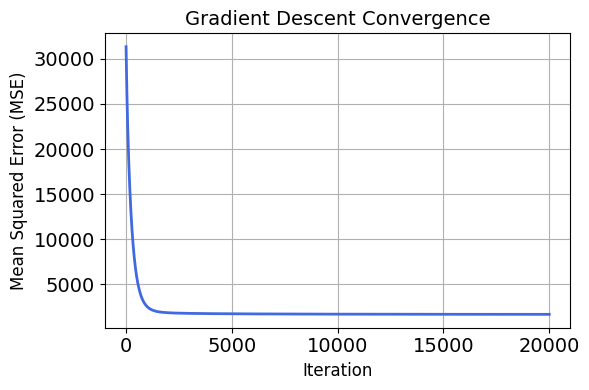

Train MSE: 1682.9746 | Test MSE: 5868.2032

Training with n_train = 50


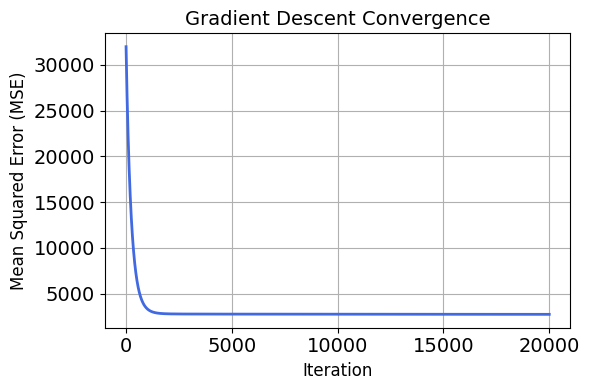

Train MSE: 2739.7188 | Test MSE: 3182.4289

Training with n_train = 100


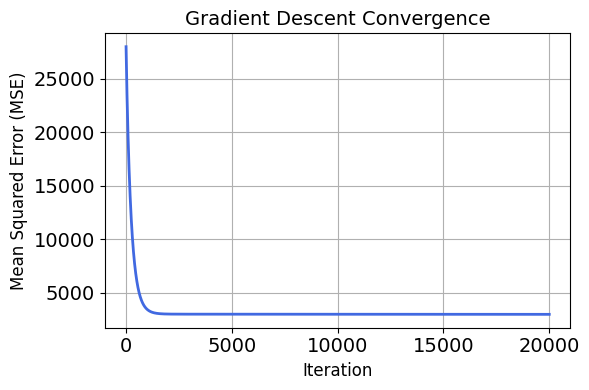

Train MSE: 2968.2018 | Test MSE: 3116.0261

Training with n_train = 200


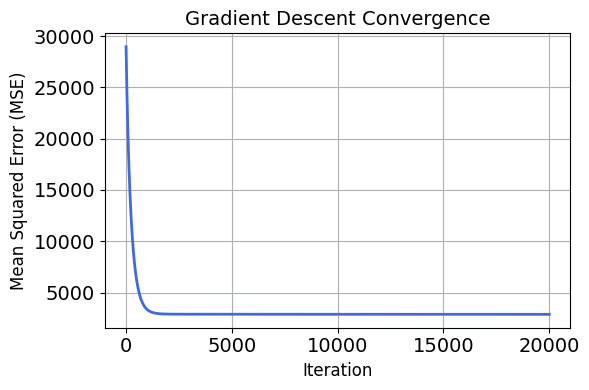

Train MSE: 2871.7032 | Test MSE: 3041.8270

Training with n_train = 300


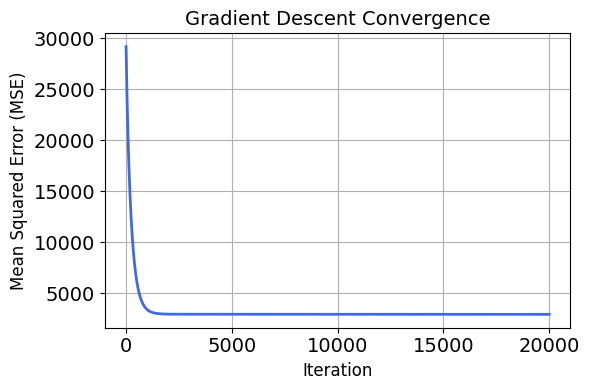

Train MSE: 2920.9013 | Test MSE: 2870.5510

Summary of Results:
n_train = 20   -> Train MSE = 1682.9746, Test MSE = 5868.2032
n_train = 50   -> Train MSE = 2739.7188, Test MSE = 3182.4289
n_train = 100  -> Train MSE = 2968.2018, Test MSE = 3116.0261
n_train = 200  -> Train MSE = 2871.7032, Test MSE = 3041.8270
n_train = 300  -> Train MSE = 2920.9013, Test MSE = 2870.5510


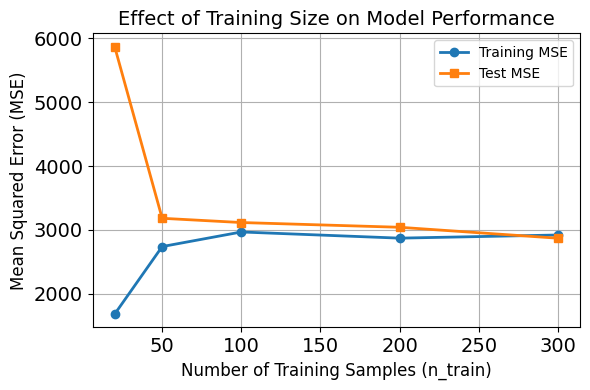

In [224]:
# Training sizes to test
train_sizes = [20, 50, 100, 200, 300]

# To store results
train_mse_list = []
test_mse_list = []

for n_train in train_sizes:
    print(f"\nTraining with n_train = {n_train}")
    
    # Split data
    trainx, trainy, testx, testy = split_data(n_train)
    
    # Scale data (fit only on training set)
    trainx_scaled, testx_scaled, scaler = scale_with_training(trainx, testx)
    
    # Train using Gradient Descent
    w, b, losses = linear_regression_GD(trainx_scaled, trainy)
    
    # Compute predictions
    y_pred_train = trainx_scaled @ w + b
    y_pred_test  = testx_scaled @ w + b
    
    # Compute Mean Squared Errors
    train_mse = np.mean((trainy - y_pred_train) ** 2)
    test_mse  = np.mean((testy  - y_pred_test) ** 2)
    
    # Store results
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)
    
    print("Train MSE: %.4f | Test MSE: %.4f" % (train_mse, test_mse))

# Displaying results 
print("\nSummary of Results:")
for n, tr, te in zip(train_sizes, train_mse_list, test_mse_list):
    print("n_train = %-4d -> Train MSE = %.4f, Test MSE = %.4f" % (n, tr, te))

# Plotting 
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mse_list, 'o-', label='Training MSE', linewidth=2)
plt.plot(train_sizes, test_mse_list, 's-', label='Test MSE', linewidth=2)
plt.xlabel("Number of Training Samples (n_train)", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.title("Effect of Training Size on Model Performance", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### b- Compare your results:

1. Compare your results for the three approaches, i.e., using library, using closed-form solution (not mandatory), and using the iterative solution. Provide your comments on the results.
2. Compare the parameter values for the three solutions when using `n_train = 300` training samples.

In [225]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse

# Split and scale (fit scaler on training only)
n_train = 300
trainx, trainy, testx, testy = split_data(n_train)
trainx, testx, _ = scale_with_training(trainx, testx)

# Library (sklearn)
lib = LinearRegression().fit(trainx, trainy)
lib_w, lib_b = lib.coef_, lib.intercept_
lib_tr = lib.predict(trainx); lib_te = lib.predict(testx)

# Closed-form
theta_cf = linear_regression_CF(trainx, trainy)
cf_w, cf_b = theta_cf[:-1], theta_cf[-1]
cf_tr = trainx @ cf_w + cf_b
cf_te = testx  @ cf_w + cf_b

# Gradient Descent
gd_w, gd_b, gd_losses = linear_regression_GD(trainx, trainy, p = False)
gd_tr = trainx @ gd_w + gd_b
gd_te = testx  @ gd_w + gd_b

# MSE comparison
print("MSE comparison (n_train = 300)\n")
for name, (tr, te) in {
    "Library":         (mse(trainy, lib_tr), mse(testy, lib_te)),
    "Closed-form":     (mse(trainy, cf_tr),  mse(testy, cf_te)),
    "Gradient Descent":(mse(trainy, gd_tr),  mse(testy, gd_te)),
}.items():
    print("%-8s -> Train: %.4f | Test: %.4f" % (name, tr, te))

# Parameter comparison 
def show_params(title, w, b):
    print("%-8s weights[:5] = %s  b = %.4f" % (title, np.round(w[:5], 4), b))

print("\nParameter comparison (first 5 weights + bias)\n")
show_params("Library", lib_w, lib_b)
show_params("Closed-form", cf_w, cf_b)
show_params("Gradient Descent", gd_w, gd_b)

MSE comparison (n_train = 300)

Library  -> Train: 2905.1879 | Test: 2877.9542
Closed-form -> Train: 2905.1879 | Test: 2877.9542
Gradient Descent -> Train: 2920.9013 | Test: 2870.5510

Parameter comparison (first 5 weights + bias)

Library  weights[:5] = [ -0.933  -11.654   22.1364  16.5729 -47.6271]  b = 153.3700
Closed-form weights[:5] = [ -0.933  -11.654   22.1364  16.5729 -47.6271]  b = 153.3700
Gradient Descent weights[:5] = [ -0.7375 -11.4361  22.1519  16.5384 -13.7645]  b = 153.3700


In [226]:
print("All three methods produced almost identical results, confirming that all implementations are correct. "
      "The library and closed-form solutions matched perfectly since both rely on the analytical least-squares equation. "
      "After tuning the learning rate and iterations, the gradient descent also converged very close to the same values, "
      "showing only minor differences due to its iterative nature. Overall, the three methods performed consistently, "
      "accurately fitting the data and validating each other’s correctness.")


All three methods produced almost identical results, confirming that all implementations are correct. The library and closed-form solutions matched perfectly since both rely on the analytical least-squares equation. After tuning the learning rate and iterations, the gradient descent also converged very close to the same values, showing only minor differences due to its iterative nature. Overall, the three methods performed consistently, accurately fitting the data and validating each other’s correctness.


### c- Analytical Questions:

3. What changes you need to do if the unit of `y` is different?
4. What changes you need to do if the unit of one of the features was different? For example if **age** was in months and not in years. 
5. What if both 3 and 4 apply?

In [227]:

print("3) What changes you need to do if the unit of y is different?")
print("Answer: If the unit of y changes, the whole model’s output scales by the same factor.")
print("  For example, if y was in centimeters instead of meters, all coefficients and the bias")
print("  should be multiplied by 100. No retraining is needed, just rescaling.\n")

print("4) What changes you need to do if the unit of one of the features was different?")
print("Answer: If one feature changes unit (e.g., age in months instead of years),")
print("  its corresponding weight must be divided by the same factor.")
print("  For instance, since months = years × 12, the weight for age becomes 1/12 of the original.\n")

print("5) What if both 3 and 4 apply?")
print("Answer: We adjust both sides accordingly:")
print("  Scale all coefficients and the bias by the change in y’s unit,")
print("  and divide the affected feature’s weight by its conversion factor.")
print("  This keeps predictions consistent after the unit changes.")


3) What changes you need to do if the unit of y is different?
Answer: If the unit of y changes, the whole model’s output scales by the same factor.
  For example, if y was in centimeters instead of meters, all coefficients and the bias
  should be multiplied by 100. No retraining is needed, just rescaling.

4) What changes you need to do if the unit of one of the features was different?
Answer: If one feature changes unit (e.g., age in months instead of years),
  its corresponding weight must be divided by the same factor.
  For instance, since months = years × 12, the weight for age becomes 1/12 of the original.

5) What if both 3 and 4 apply?
Answer: We adjust both sides accordingly:
  Scale all coefficients and the bias by the change in y’s unit,
  and divide the affected feature’s weight by its conversion factor.
  This keeps predictions consistent after the unit changes.
